# Response matrix (effective aperture)

For some workflows it is convenient to precompute the per-pixel
response of a telescope+camera pair as a function of stellar
position. Camera.response_matrix does this in a single render
pass: it traces all sources at once and scatters the resulting
rays into a (n_sources, n_sensors, *pixel_shape) array.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from iactrace import Camera, Telescope

## Load HESS CT3

In [2]:
telescope = Telescope.from_yaml(
    '../../configs/HESS/CT3.yaml',
    n_samples=1,
    key=jax.random.key(42),
)
telescope = telescope.apply_roughness(0, 24)

camera = Camera.from_yaml('../../configs/HESS/HESS1U.yaml')

E0508 14:48:20.088263 1765158 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]
E0508 14:48:20.088379 1765159 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]
E0508 14:48:20.088467 1765160 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]


## Sample a grid of stellar directions

We tile a square in the field of view; each row of the response
matrix will be the per-pixel response to a single direction.

In [3]:
fov_deg = 5.5
fov_rad = fov_deg * jnp.pi / 180

n_side = 128
x1d = jnp.linspace(-fov_rad / 2, fov_rad / 2, n_side)
y1d = jnp.linspace(-fov_rad / 2, fov_rad / 2, n_side)
X, Y = jnp.meshgrid(x1d, y1d, indexing='xy')
z = -jnp.ones(n_side ** 2)

sources = jnp.stack([X.ravel(), Y.ravel(), z], axis=1)
sources = sources / jnp.linalg.norm(sources, axis=1, keepdims=True)

## Compute the response matrix

Output shape is `(n_sources, n_sensors, n_pixels)`. CT3 has a
single hexagonal sensor group with 960 pixels.

In [4]:
rm = camera.response_matrix(
    telescope.render(sources, jnp.ones(sources.shape[0]), source_type='parallel'),
    sensor_idx=0,
)
rm.shape

(16384, 1, 960)

## Total effective aperture per source

Sum across pixels and reshape onto the source grid:

Text(0, 0.5, 'y [rad]')

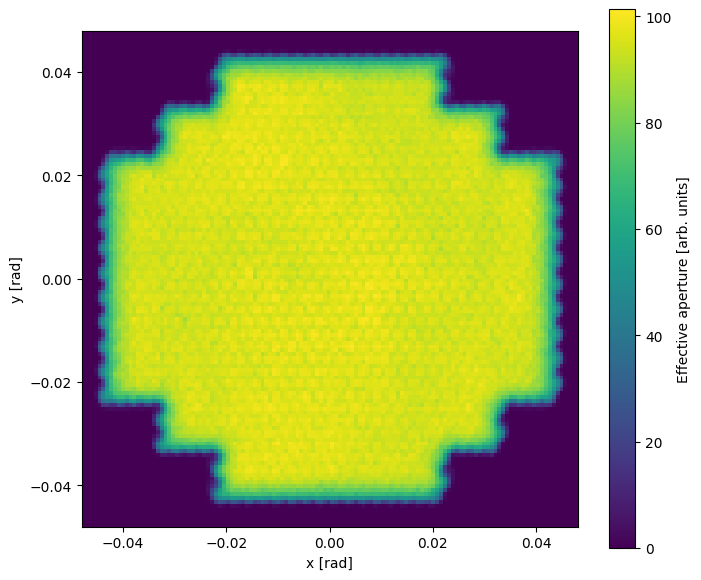

In [5]:
weights = rm.sum(axis=(1, 2)).reshape(n_side, n_side)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(
    weights, origin='lower',
    extent=[x1d[0], x1d[-1], y1d[0], y1d[-1]],
)
fig.colorbar(im, ax=ax, label='Effective aperture [arb. units]')
ax.set_xlabel('x [rad]')
ax.set_ylabel('y [rad]')

## Per-pixel effective aperture

Pick a single pixel (e.g. pixel 300) and visualise where on the
sky an incoming photon ends up in that pixel.

Text(0, 0.5, 'y [rad]')

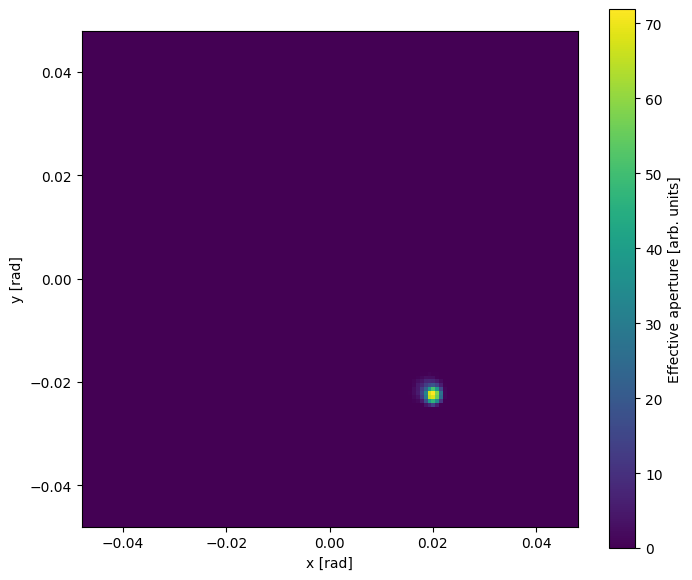

In [6]:
pixel_id = 300
weights_pix = rm[:, 0, pixel_id].reshape(n_side, n_side)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(
    weights_pix, origin='lower',
    extent=[x1d[0], x1d[-1], y1d[0], y1d[-1]],
)
fig.colorbar(im, ax=ax, label='Effective aperture [arb. units]')
ax.set_xlabel('x [rad]')
ax.set_ylabel('y [rad]')

## Re-rendering after misalignment

`response_matrix` is a thin wrapper around the regular render
path, so functional updates to the telescope (e.g. random
misalignment) compose naturally.

Text(0, 0.5, 'y [rad]')

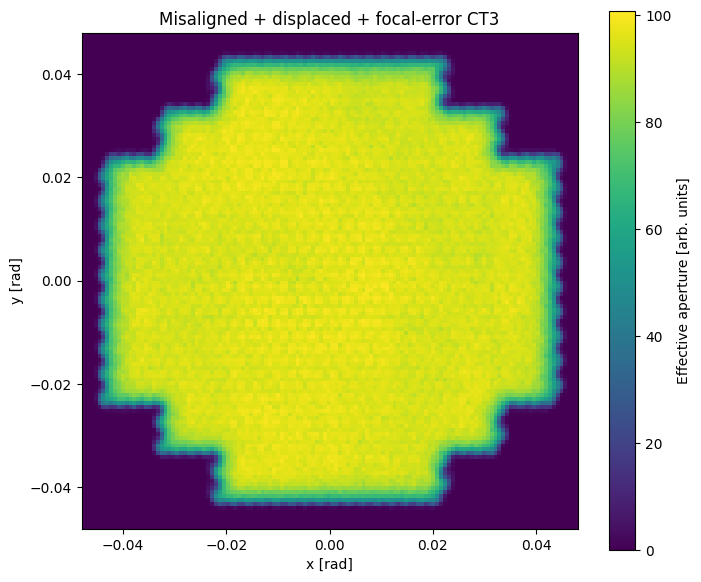

In [8]:
perturbed = (
    telescope.apply_misalignment(0, 15, 10, jax.random.key(0))
             .apply_displacement(0, 0.02, jax.random.key(1))
             .apply_focal_error(0, 0.07, jax.random.key(2))
)
rm_p = camera.response_matrix(
    perturbed.render(sources, jnp.ones(sources.shape[0]), source_type='parallel'),
    sensor_idx=0,
)
weights_p = rm_p.sum(axis=(1, 2)).reshape(n_side, n_side)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(
    weights_p, origin='lower',
    extent=[x1d[0], x1d[-1], y1d[0], y1d[-1]],
)
fig.colorbar(im, ax=ax, label='Effective aperture [arb. units]')
ax.set_title('Misaligned + displaced + focal-error CT3')
ax.set_xlabel('x [rad]')
ax.set_ylabel('y [rad]')